In [1]:
#import all the required libraries
from Configurations.imports import *

In [4]:
# import the data store path
from Configurations.file_path import base, data_parent_path
file_path = data_parent_path / "economic_index.csv"

In [6]:
df = pd.read_csv(file_path)
df.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [15]:
#drop the unwanted column
# df.drop("Unnamed: 0", inplace=True, axis=1)
df.head()

,year,month,interest_rate,unemployment_rate,index_price
0,2017,12,2.75,5.3,1464
1,2017,11,2.50,5.3,1394
2,2017,10,2.50,5.3,1357
3,2017,9,2.50,5.3,1293
4,2017,8,2.50,5.4,1256


In [16]:
df.drop(columns=["year","month"], inplace=True, axis=1)

In [17]:
df.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [18]:
# check if there is any null values
df.isna().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

In [19]:
# check the relationships between the features
df.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


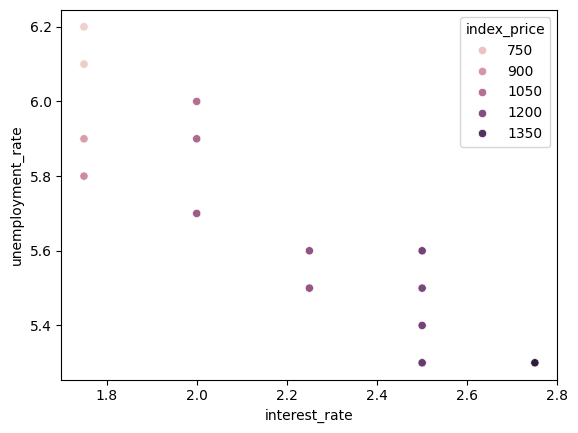

In [22]:
# visualize with help of scatter plot
sns.scatterplot(x="interest_rate", y="unemployment_rate", hue="index_price", data=df)
plt.xlabel("interest_rate")
plt.ylabel("unemployment_rate")
plt.show()

In [ ]:
# segregate the independent and dependent features
x = df.iloc[:,:-1] #independent 
y = df.iloc[:,-1] #dependent

pandas.core.series.Series

In [26]:
# splitting the data into train and test data
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.25, random_state=42)

In [27]:
# standardize the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(x_train)
X_test = scaler.fit(x_test)

In [ ]:
#apply the linear regression 

from sklearn.linear_model import LinearRegression
regressor = LinearRegression(n_jobs=-1)
regressor.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,-1
,positive,False


In [ ]:
#predict the output values for the test data
y_pred = regressor.predict(x_test)

In [32]:
# Performance Checking
from sklearn.metrics import mean_squared_error, mean_absolute_error

print("mean squared error: ", mean_squared_error(y_test, y_pred))
print("mean absolute error: ", mean_absolute_error(y_test, y_pred))
print("Root mean squared error: " , np.sqrt(mean_absolute_error(y_test, y_pred)))

mean squared error:  5793.762887712549
mean absolute error:  59.93578152323547
Root mean squared error:  7.7418202977875605


In [ ]:
from sklearn.metrics import r2_scor
score = r2_score(y_test, y_pred)
print("model accuracy is: " , score.__round__(2) * 100)

model accuracy is:  83.0


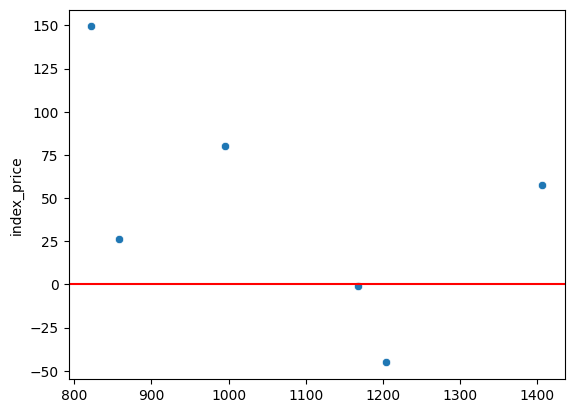

In [ ]:
residuals = y_test - y_pred

sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red')
# Random scatter around 0

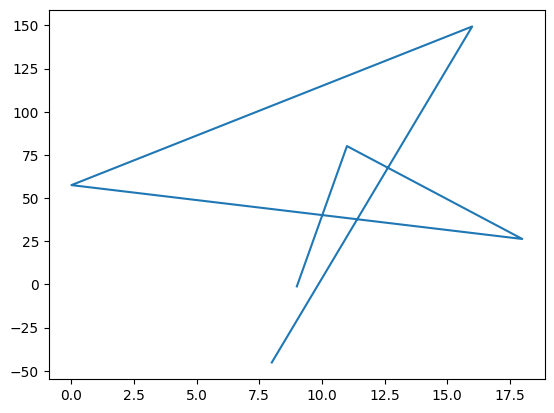

In [ ]:
plt.plot(residuals)
#No pattern, random noise

<Axes: xlabel='index_price', ylabel='Count'>

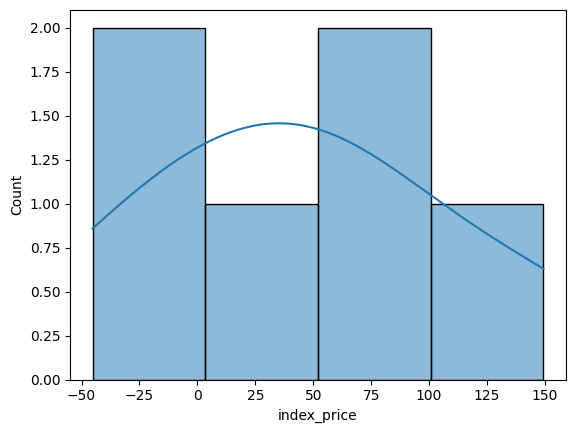

In [ ]:
sns.histplot(residuals, kde=True)
# Bell-shaped curve